In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import gc
import warnings

warnings.filterwarnings('ignore')

print("=" * 50)
print("Kütüphaneler yüklendi ✓")
print(f"  Pandas : {pd.__version__}")
print(f"  NumPy  : {np.__version__}")
print("=" * 50)

Kütüphaneler yüklendi ✓
  Pandas : 3.0.1
  NumPy  : 2.4.3


In [3]:
csv_dir = "../data/csv"

# Sadece ham CIC-IDS2017 dosyalarını al;
# daha önce ürettiğimiz combined/cleaned gibi dosyaları dışla.
EXCLUDE_PREFIXES = ("combined", "cleaned", "sampled")

csv_files = sorted([
    f for f in os.listdir(csv_dir)
    if f.endswith(".csv") and not f.startswith(EXCLUDE_PREFIXES)
])

print(f"Bulunan ham CSV dosyaları ({len(csv_files)} adet):\n")
for f in csv_files:
    size_mb = os.path.getsize(os.path.join(csv_dir, f)) / (1024 * 1024)
    print(f"  {f:<65} ({size_mb:6.1f} MB)")

Bulunan ham CSV dosyaları (10 adet):

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  (  73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv              (  73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv                         (  55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv                                 ( 168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv       (  79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv            (  49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv                                ( 128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv                              ( 214.7 MB)
  featured_dataset.csv                                              ( 139.6 MB)
  label_mapping.csv                                                 (   0.0 MB)


In [4]:
# Hücre 3 — Ham Veriyi Keşif (EDA: Ön Tarama) - GÜNCELLENMİŞ
raw_summary = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)
    
    # Sütun isimlerini kontrol et (Boşluk sorununu çözmek için)
    # İlk satırı oku ve sütun isimlerini temizle
    temp_cols = pd.read_csv(fpath, nrows=0).columns.str.strip()
    
    # Gerçek "Label" sütun adını bul (Büyük/küçük harf veya boşluk fark etmeksizin)
    actual_label_col = next((c for c in pd.read_csv(fpath, nrows=0).columns if c.strip() == "Label"), None)
    
    if actual_label_col is None:
        print(f"⚠ HATA: {f} dosyasında 'Label' sütunu bulunamadı!")
        continue

    # Şimdi sadece o dosyaya özel 'actual_label_col' ismini kullanarak oku
    df_temp = pd.read_csv(fpath, usecols=[actual_label_col], encoding="utf-8", low_memory=False)
    
    # Standartlaştırma: Kolon adını 'Label' yap ve değerleri temizle
    df_temp.columns = ["Label"]
    df_temp["Label"] = df_temp["Label"].astype(str).str.strip()
    
    # Encoding bozukluğunu düzelt
    df_temp["Label"] = df_temp["Label"].replace({
        "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
        "Web Attack \ufffd XSS"          : "Web Attack - XSS",
        "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
    })
    
    counts = df_temp["Label"].value_counts().to_dict()
    total  = len(df_temp)
    benign = counts.get("BENIGN", 0)
    attack = total - benign
    
    raw_summary.append({
        "source_file"  : f,
        "total_rows"   : total,
        "benign_rows"  : benign,
        "attack_rows"  : attack,
        "label_counts" : counts,
    })
    
    print(f"✓ {f}")
    print(f"    Toplam: {total:>10,}  |  Benign: {benign:>10,}  |  Attack: {attack:>10,}")
    for label, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        if label != "BENIGN":
            print(f"      └─ {label:<40} {cnt:>8,}")
    print()
    
    del df_temp
    gc.collect()

# ... (Hücrenin geri kalan görselleştirme/print kısımları aynı kalabilir)

# Tüm dosyalardaki ham label dağılımı
all_labels: dict[str, int] = {}
for row in raw_summary:
    for label, cnt in row["label_counts"].items():
        all_labels[label] = all_labels.get(label, 0) + cnt

print("=" * 60)
print("TÜM VERİDEKİ HAM SINIF DAĞILIMI (sampling öncesi)")
print("=" * 60)
for label, cnt in sorted(all_labels.items(), key=lambda x: -x[1]):
    bar = "█" * (cnt // 10000)
    print(f"  {label:<40} {cnt:>9,}  {bar}")

total_benign_raw = all_labels.get("BENIGN", 0)
total_attack_raw = sum(v for k, v in all_labels.items() if k != "BENIGN")
print(f"\n  Toplam BENIGN : {total_benign_raw:>9,}")
print(f"  Toplam ATTACK : {total_attack_raw:>9,}")
print(f"  Benign oranı  : %{total_benign_raw / (total_benign_raw + total_attack_raw) * 100:.1f}")

✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Toplam:    225,745  |  Benign:     97,718  |  Attack:    128,027
      └─ DDoS                                      128,027

✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Toplam:    286,467  |  Benign:    127,537  |  Attack:    158,930
      └─ PortScan                                  158,930

✓ Friday-WorkingHours-Morning.pcap_ISCX.csv
    Toplam:    191,033  |  Benign:    189,067  |  Attack:      1,966
      └─ Bot                                         1,966

✓ Monday-WorkingHours.pcap_ISCX.csv
    Toplam:    529,918  |  Benign:    529,918  |  Attack:          0

✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Toplam:    288,602  |  Benign:    288,566  |  Attack:         36
      └─ Infiltration                                   36

✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Toplam:    170,366  |  Benign:    168,186  |  Attack:      2,180
      └─ Web Attack - Brute Force       

In [5]:
RANDOM_STATE = 42

# ── Benign Parametreleri ─────────────────────────────────────────────────────
# Her kaynak dosyadan alınacak maksimum benign satır sayısı.
# 50K × 8 dosya = en fazla 400K benign → Monday monopolisi kırılır.
BENIGN_CAP_PER_FILE = 50_000

# ── Attack Parametreleri ─────────────────────────────────────────────────────
# DoS Hulk (231K), PortScan (159K), DDoS (128K) gibi dev sınıflar
# diğer sınıfları ezer. Bu cap aşağıdaki sınıfları dengeler.
ATTACK_CAP_PER_CLASS = 30_000

# ── Çıkarılacak Sınıflar (Rare / Hatalı Etiket) ─────────────────────────────
# Heartbleed (11), Sql Injection (21), Infiltration (36):
# - Örnek sayısı modeli eğitmek için yetersiz
# - Infiltration etiket hataları CIC-IDS2017 literatüründe belgelenmiş (R7, R14)
# - Bu sınıfları bırakmak multiclass F1'i yapay olarak bozar
EXCLUDE_LABELS = {
    "Heartbleed",
    "Web Attack - Sql Injection",
    "Infiltration",
}

print("Sampling Stratejisi:")
print(f"  Benign cap (dosya başına) : {BENIGN_CAP_PER_FILE:,}")
print(f"  Attack cap (sınıf başına) : {ATTACK_CAP_PER_CLASS:,}")
print(f"  Çıkarılan sınıflar        : {EXCLUDE_LABELS}")
print(f"  Random state              : {RANDOM_STATE}")

Sampling Stratejisi:
  Benign cap (dosya başına) : 50,000
  Attack cap (sınıf başına) : 30,000
  Çıkarılan sınıflar        : {'Heartbleed', 'Web Attack - Sql Injection', 'Infiltration'}
  Random state              : 42


In [6]:
sampled_parts = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)
    
    # Tüm dosyayı oku
    df_temp = pd.read_csv(fpath, encoding="utf-8", low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()          # CIC-IDS2017 whitespace sorunu (R7)
    df_temp["source_file"] = f                              # Kaynak takibi için kritik
    
    # Label temizliği
    df_temp["Label"] = df_temp["Label"].astype(str).str.strip()
    df_temp["Label"] = df_temp["Label"].replace({
        "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
        "Web Attack \ufffd XSS"          : "Web Attack - XSS",
        "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
    })
    
    # Rare / hatalı sınıfları çıkar
    df_temp = df_temp[~df_temp["Label"].isin(EXCLUDE_LABELS)].copy()
    
    # ── BENIGN SAMPLING ──────────────────────────────────────────────────────
    benign_pool = df_temp[df_temp["Label"] == "BENIGN"]
    n_benign    = min(BENIGN_CAP_PER_FILE, len(benign_pool))
    benign_sample = benign_pool.sample(n=n_benign, random_state=RANDOM_STATE)
    
    # ── ATTACK SAMPLING (sınıf bazında cap) ──────────────────────────────────
    attack_pool  = df_temp[df_temp["Label"] != "BENIGN"]
    attack_parts = []
    
    for label, group in attack_pool.groupby("Label"):
        n_attack = min(ATTACK_CAP_PER_CLASS, len(group))
        attack_parts.append(group.sample(n=n_attack, random_state=RANDOM_STATE))
    
    attack_sample = pd.concat(attack_parts, ignore_index=True) if attack_parts else pd.DataFrame()
    
    # ── BİRLEŞTİR ────────────────────────────────────────────────────────────
    file_df = pd.concat([benign_sample, attack_sample], ignore_index=True)
    sampled_parts.append(file_df)
    
    print(f"✓ {f}")
    print(f"    Benign : {len(benign_pool):>8,} → sample {n_benign:>6,}")
    if attack_parts:
        for label, group in attack_pool.groupby("Label"):
            taken = min(ATTACK_CAP_PER_CLASS, len(group))
            capped = " (CAPPED)" if len(group) > ATTACK_CAP_PER_CLASS else ""
            print(f"    Attack [{label:<35}]: {len(group):>6,} → {taken:>6,}{capped}")
    else:
        print("    Attack : yok")
    print()
    
    del df_temp, benign_pool, benign_sample, attack_pool, attack_sample
    gc.collect()

✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Benign :   97,718 → sample 50,000
    Attack [DDoS                               ]: 128,027 → 30,000 (CAPPED)

✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Benign :  127,537 → sample 50,000
    Attack [PortScan                           ]: 158,930 → 30,000 (CAPPED)

✓ Friday-WorkingHours-Morning.pcap_ISCX.csv
    Benign :  189,067 → sample 50,000
    Attack [Bot                                ]:  1,966 →  1,966

✓ Monday-WorkingHours.pcap_ISCX.csv
    Benign :  529,918 → sample 50,000
    Attack : yok

✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Benign :  288,566 → sample 50,000
    Attack : yok

✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Benign :  168,186 → sample 50,000
    Attack [Web Attack - Brute Force           ]:  1,507 →  1,507
    Attack [Web Attack - XSS                   ]:    652 →    652

✓ Tuesday-WorkingHours.pcap_ISCX.csv
    Benign :  432,074 → sample 50,000
  

KeyError: 'Label'

In [ ]:
df_combined = pd.concat(sampled_parts, ignore_index=True)

# ── Sınıf Dağılımı ───────────────────────────────────────────────────────────
label_dist  = df_combined["Label"].value_counts()
source_dist = df_combined["source_file"].value_counts()

total_rows   = len(df_combined)
total_benign = (df_combined["Label"] == "BENIGN").sum()
total_attack = total_rows - total_benign

print("=" * 65)
print("BİRLEŞİK DATASET ÖZETİ")
print("=" * 65)
print(f"  Toplam satır    : {total_rows:>9,}")
print(f"  Toplam benign   : {total_benign:>9,}  (%{total_benign/total_rows*100:.1f})")
print(f"  Toplam attack   : {total_attack:>9,}  (%{total_attack/total_rows*100:.1f})")
print(f"  Sütun sayısı    : {df_combined.shape[1]}")
print()

print("Sınıf dağılımı:")
for label, cnt in label_dist.items():
    pct = cnt / total_rows * 100
    print(f"  {label:<40} {cnt:>8,}  (%{pct:4.1f})")

print()
print("Kaynak dosya dağılımı:")
for src, cnt in source_dist.items():
    pct = cnt / total_rows * 100
    print(f"  {src:<65} {cnt:>7,}  (%{pct:4.1f})")

BİRLEŞİK DATASET ÖZETİ
  Toplam satır    :   529,548
  Toplam benign   :   400,000  (%75.5)
  Toplam attack   :   129,548  (%24.5)
  Sütun sayısı    : 80

Sınıf dağılımı:
  BENIGN                                    400,000  (%75.5)
  DDoS                                       30,000  (% 5.7)
  PortScan                                   30,000  (% 5.7)
  DoS Hulk                                   30,000  (% 5.7)
  DoS GoldenEye                              10,293  (% 1.9)
  FTP-Patator                                 7,938  (% 1.5)
  SSH-Patator                                 5,897  (% 1.1)
  DoS slowloris                               5,796  (% 1.1)
  DoS Slowhttptest                            5,499  (% 1.0)
  Bot                                         1,966  (% 0.4)
  Web Attack - Brute Force                    1,507  (% 0.3)
  Web Attack - XSS                              652  (% 0.1)

Kaynak dosya dağılımı:
  Wednesday-workingHours.pcap_ISCX.csv                              101,5

In [ ]:
output_path = "../data/csv/combined_dataset.csv"

df_combined.to_csv(output_path, index=False)

size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"✓ Dataset kaydedildi: {output_path}")
print(f"  Boyut  : {size_mb:.1f} MB")
print(f"  Satır  : {len(df_combined):,}")
print(f"  Sütun  : {df_combined.shape[1]}")

✓ Dataset kaydedildi: ../data/csv/combined_dataset.csv
  Boyut  : 195.4 MB
  Satır  : 529,548
  Sütun  : 80


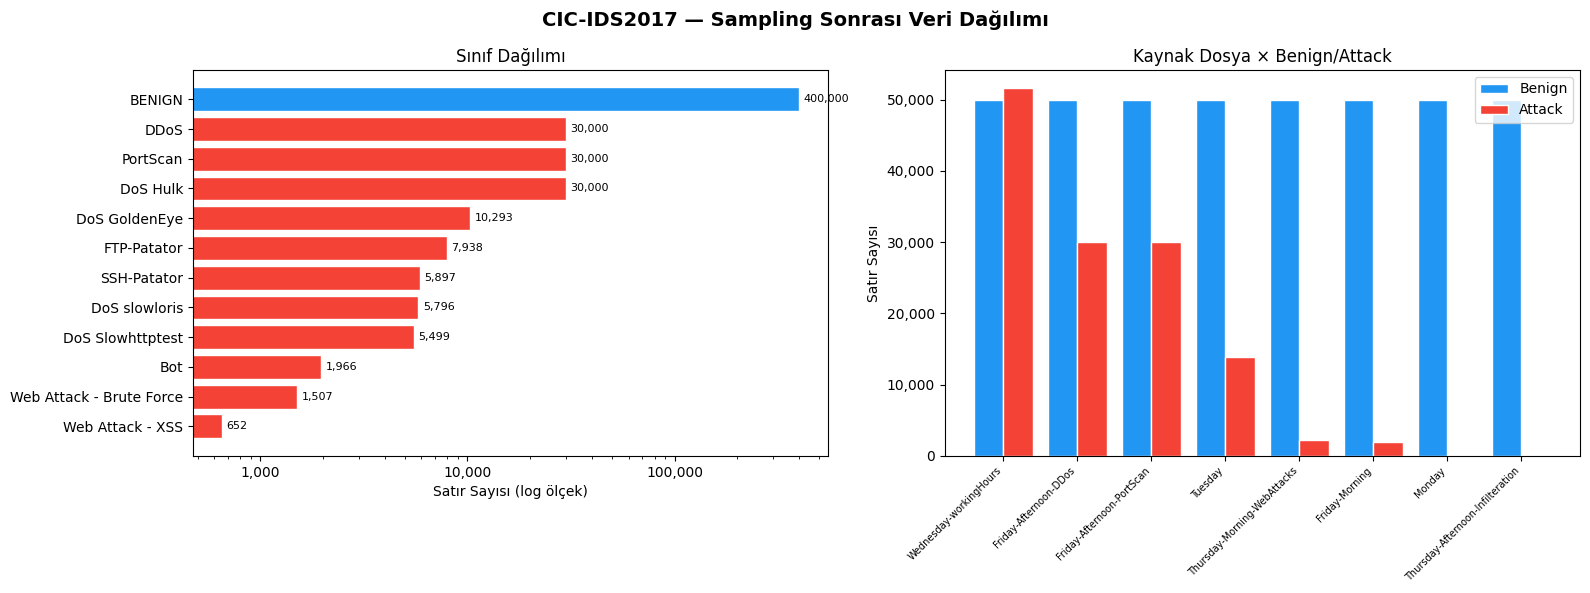

✓ Grafik kaydedildi: ../data/csv/dataset_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CIC-IDS2017 — Sampling Sonrası Veri Dağılımı", fontsize=14, fontweight="bold")

# ── Sol: Sınıf dağılımı (log scale, çünkü aralık büyük) ─────────────────────
ax = axes[0]
labels_plot  = label_dist.index.tolist()
counts_plot  = label_dist.values.tolist()
colors       = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_plot]

bars = ax.barh(labels_plot[::-1], counts_plot[::-1], color=colors[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Satır Sayısı (log ölçek)")
ax.set_title("Sınıf Dağılımı")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, cnt in zip(bars, counts_plot[::-1]):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", ha="left", fontsize=8)

# ── Sağ: Kaynak dosya bazında benign / attack dağılımı ───────────────────────
ax = axes[1]
src_benign = df_combined[df_combined["Label"] == "BENIGN"]["source_file"].value_counts()
src_attack = df_combined[df_combined["Label"] != "BENIGN"]["source_file"].value_counts()

src_names_short = [s.replace("-WorkingHours", "").replace(".pcap_ISCX.csv", "")
                   for s in source_dist.index]

x  = np.arange(len(source_dist))
w  = 0.4
b1 = ax.bar(x - w/2, [src_benign.get(s, 0) for s in source_dist.index],
            w, label="Benign", color="#2196F3", edgecolor="white")
b2 = ax.bar(x + w/2, [src_attack.get(s, 0) for s in source_dist.index],
            w, label="Attack", color="#F44336", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(src_names_short, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Satır Sayısı")
ax.set_title("Kaynak Dosya × Benign/Attack")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()

plt.tight_layout()
plt.savefig("../data/csv/dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Grafik kaydedildi: ../data/csv/dataset_distribution.png")

In [ ]:
print("=" * 60)
print("KALİTE KONTROL")
print("=" * 60)

# 1. source_file kolonu var mı?
assert "source_file" in df_combined.columns, "HATA: source_file kolonu yok!"
print("✓ source_file kolonu mevcut")

# 2. Label kolonu var mı?
assert "Label" in df_combined.columns, "HATA: Label kolonu yok!"
print("✓ Label kolonu mevcut")

# 3. Exclude edilen sınıflar dataset'te yok mu?
found_excluded = df_combined[df_combined["Label"].isin(EXCLUDE_LABELS)]["Label"].unique()
assert len(found_excluded) == 0, f"HATA: Çıkarılması gereken sınıflar hâlâ var: {found_excluded}"
print(f"✓ Rare/hatalı sınıflar temizlendi: {EXCLUDE_LABELS}")

# 4. Her kaynak dosya sampling'e girdi mi?
sampled_sources = df_combined["source_file"].unique()
missing = set(csv_files) - set(sampled_sources)
if missing:
    print(f"⚠ Şu dosyalardan hiç satır alınamadı: {missing}")
else:
    print(f"✓ Tüm {len(csv_files)} dosya sampling'e girdi")

# 5. Benign oranı makul aralıkta mı? (%50–%85 beklenebilir)
benign_pct = total_benign / total_rows * 100
assert 40 <= benign_pct <= 90, f"HATA: Benign oranı anormal → %{benign_pct:.1f}"
print(f"✓ Benign oranı makul: %{benign_pct:.1f}")

# 6. NaN / Inf var mı? (temizlik notebook 02'de ama erken uyarı)
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
n_inf = np.isinf(df_combined[numeric_cols].values).sum()
n_nan = df_combined[numeric_cols].isna().sum().sum()
print(f"  Inf sayısı (ham) : {n_inf:,}  → notebook 02'de temizlenecek")
print(f"  NaN sayısı (ham) : {n_nan:,}  → notebook 02'de temizlenecek")

print()
print("=" * 60)
print("DATASET HAZIR → sonraki adım: 02_data_cleaning.ipynb")
print("=" * 60)

KALİTE KONTROL
✓ source_file kolonu mevcut
✓ Label kolonu mevcut
✓ Rare/hatalı sınıflar temizlendi: {'Web Attack - Sql Injection', 'Heartbleed', 'Infiltration'}
✓ Tüm 8 dosya sampling'e girdi
✓ Benign oranı makul: %75.5
  Inf sayısı (ham) : 760  → notebook 02'de temizlenecek
  NaN sayısı (ham) : 172  → notebook 02'de temizlenecek

DATASET HAZIR → sonraki adım: 02_data_cleaning.ipynb
